In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from scipy.signal import convolve2d
import torch
import json

# from mlp import Linear, MLP
from utils import discrete_2d_convolution

In [38]:
# From a file (loaded as grayscale)
image_path = 'data/dog_painting.tiff'
image = np.array(Image.open(image_path).convert('L'))  # shape: [H, W], dtype: uint8

In [39]:
kernel_w = 3
kernel_shape = (kernel_w, kernel_w)
kernel_length = kernel_shape[0] * kernel_shape[1]
kernel_value = 1.0 / kernel_length
kernel = np.full(kernel_shape, kernel_value)
kernel

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [40]:
kernel_shape = (30, 30)
kernel_length = kernel_shape[0] * kernel_shape[1]
kernel_value = 1.0 / kernel_length
kernel = np.full(kernel_shape, kernel_value)
convolved_image = discrete_2d_convolution(image, kernel)

# naive implementation runs in 46.8s for 30x30 kernel


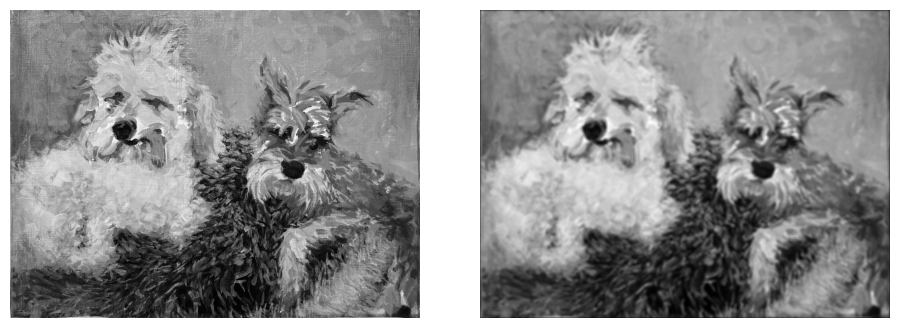

In [41]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax = axes[0]
ax.imshow(image, cmap='gray')
ax.axis('off')

ax = axes[1]
ax.imshow(convolved_image, cmap='gray')
ax.axis('off')

plt.subplots_adjust(wspace=0.02)
plt.show()

In [42]:
print(image.shape)
print(convolved_image.shape)

(2890, 3841)
(2890, 3841)


In [43]:
sci_convolved_image = convolve2d(image, kernel)
# runs in 15.6s with 30x30 kernel

In [44]:
def create_sobel_kernels(width):
    if width % 2 == 0:
        raise ValueError("Width must be an odd integer (e.g., 3, 5, 7, 9).")

    # 1. Create the Smoothing Vector (Binomial Coefficients / Pascal's Triangle)
    # For width 3, this is [1, 2, 1]. For width 9, it follows a bell curve.
    base = np.array([1, 1])
    smoothing = base.copy()
    for _ in range(width - 2):
        smoothing = np.convolve(smoothing, base)
    
    # 2. Create the Derivative Vector
    # This represents the change (gradient).
    derivative = np.zeros(width)
    center = width // 2
    for i in range(width):
        derivative[i] = i - center
        
    # 3. Create Kernels via Outer Product
    # Vertical Kernel (detects horizontal changes)
    # We smooth vertically and take the derivative horizontally
    sobel_x = np.outer(smoothing, derivative)
    
    # Horizontal Kernel (detects vertical changes)
    # We smooth horizontally and take the derivative vertically
    sobel_y = np.outer(derivative, smoothing)
    
    return sobel_x, sobel_y

# Generate 9x9 Kernels


In [45]:
def high_contrast(img):
    return np.abs(img)

In [ ]:
kernel_vertical_9, kernel_horizontal_9 = create_sobel_kernels(9)
convolved_image_vertical_9 = discrete_2d_convolution(image, kernel_vertical_9)
convolved_image_horizontal_9 = discrete_2d_convolution(image, kernel_horizontal_9)

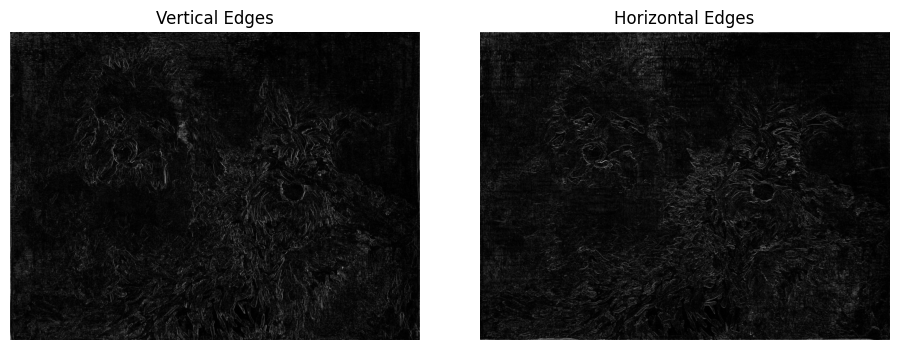

In [47]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax = axes[0]
ax.imshow(high_contrast(convolved_image_vertical_9), cmap='gray')
ax.set_title('Vertical Edges')
ax.axis('off')

ax = axes[1]
ax.imshow(high_contrast(convolved_image_horizontal_9), cmap='gray')
ax.set_title('Horizontal Edges')
ax.axis('off')

plt.subplots_adjust(wspace=0.02)
plt.show()

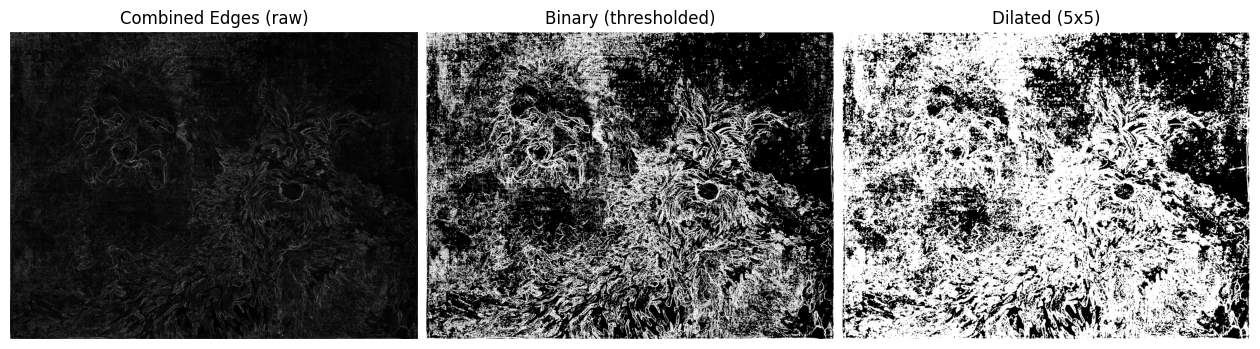

In [50]:
# Dilation: expand light pixels by making all neighbors light too
# 1. Binarize the edge-detected image (threshold at median of non-zero values)
edge_img = high_contrast(convolved_image_vertical_9) + high_contrast(convolved_image_horizontal_9)
threshold = np.percentile(edge_img[edge_img > 0], 70)
binary = (edge_img > threshold).astype(np.float64) * 255

# 2. Dilation kernel — a 5x5 block of ones. Convolving with this spreads each bright pixel
#    to all neighbors within a 5x5 window. Any overlap with a bright pixel → bright output.
dilate_kernel = np.ones((5, 5))
dilated = convolve2d(binary, dilate_kernel, mode='same')
dilated = (dilated > 0).astype(np.float64) * 255  # re-binarize after dilation

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].imshow(edge_img, cmap='gray')
axes[0].set_title('Combined Edges (raw)')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary (thresholded)')
axes[1].axis('off')

axes[2].imshow(dilated, cmap='gray')
axes[2].set_title('Dilated (5x5)')
axes[2].axis('off')

plt.subplots_adjust(wspace=0.02)
plt.show()

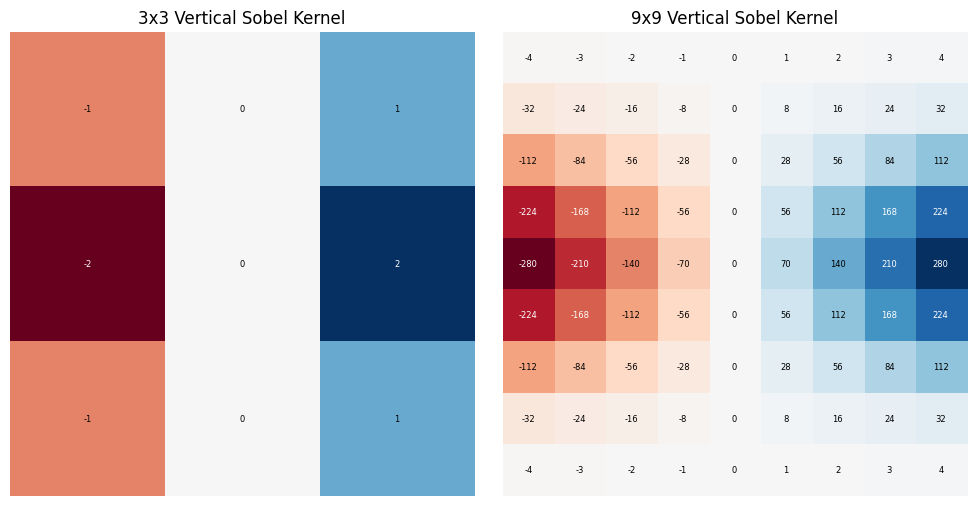

In [49]:
# visualize both the 3x3 and 9x9 vertical Sobel kernels side by side
from matplotlib.colors import TwoSlopeNorm

kernel_vertical_3, _ = create_sobel_kernels(3)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, kernel, title in [
    (axes[0], kernel_vertical_3, '3x3 Vertical Sobel Kernel'),
    (axes[1], kernel_vertical_9, '9x9 Vertical Sobel Kernel'),
]:
    norm = TwoSlopeNorm(vmin=kernel.min(), vcenter=0, vmax=kernel.max())
    im = ax.imshow(kernel, cmap='RdBu', norm=norm)
    for i in range(kernel.shape[0]):
        for j in range(kernel.shape[1]):
            val = kernel[i, j]
            color = 'white' if abs(val) > kernel.max() * 0.5 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=6, color=color)
    ax.set_title(title)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
kernel_vertical_3, kernel_horizontal_3 = create_sobel_kernels(3)
convolved_image_vertical_3 = discrete_2d_convolution(image, kernel_vertical_3)
convolved_image_horizontal_3 = discrete_2d_convolution(image, kernel_horizontal_3)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

ax = axes[0]
ax.imshow(high_contrast(convolved_image_vertical_3), cmap='gray')
ax.set_title('Vertical Edges')
ax.axis('off')

ax = axes[1]
ax.imshow(high_contrast(convolved_image_horizontal_3), cmap='gray')
ax.set_title('Horizontal Edges')
ax.axis('off')

plt.subplots_adjust(wspace=0.02)
plt.show()

In [ ]:
np.max(convolved_image_horizontal_3)
np.min(convolved_image_horizontal_3)

np.float64(-887.0)

## Practical - Question 2

In [ ]:
import pandas as pd

In [ ]:
mlp_df = pd.read_json('data/mlp_25_results.json')
mn_df = pd.read_json('data/mobile_net_25_results.json')

In [ ]:
mlp_df

,train_losses,valid_losses,train_accs,valid_accs,train_times,valid_times,test_loss,test_acc,test_time
0,0.010852,0.009426,0.472940,0.555083,36.028176,2.039438,0.009586,0.64894,1.510822
1,0.009149,0.008908,0.558355,0.576206,36.278461,1.977696,0.009586,0.64894,1.510822
2,0.008643,0.008809,0.582937,0.567366,35.054670,2.950587,0.009586,0.64894,1.510822
3,0.008250,0.008285,0.600107,0.595530,35.493925,1.980021,0.009586,0.64894,1.510822
4,0.007807,0.007596,0.621366,0.641179,36.524041,1.994829,0.009586,0.64894,1.510822
5,0.007265,0.007373,0.644681,0.630637,36.492866,2.019796,0.009586,0.64894,1.510822
6,0.006918,0.007215,0.660440,0.651483,36.455932,2.224674,0.009586,0.64894,1.510822
7,0.006693,0.006926,0.668952,0.665526,34.480622,3.028740,0.009586,0.64894,1.510822
8,0.006566,0.006622,0.675476,0.668078,35.869650,2.145013,0.009586,0.64894,1.510822
9,0.006419,0.006385,0.682688,0.689636,36.187475,2.018945,0.009586,0.64894,1.510822


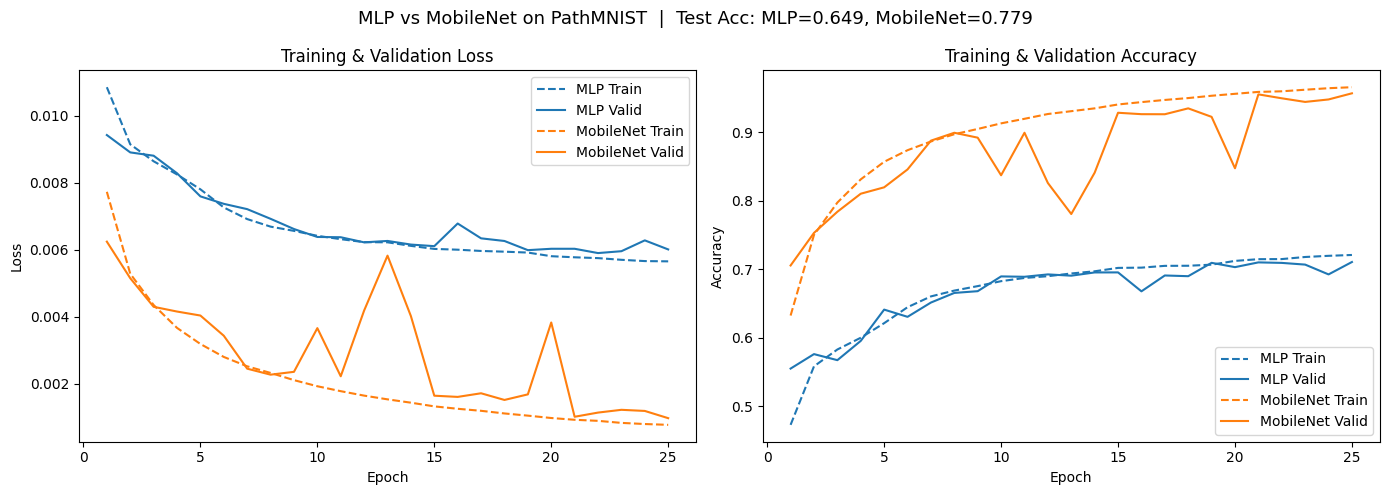

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(mlp_df) + 1)

# Loss plot
ax = axes[0]
ax.plot(epochs, mlp_df['train_losses'], label='MLP Train', linestyle='--', color='tab:blue')
ax.plot(epochs, mlp_df['valid_losses'], label='MLP Valid', color='tab:blue')
ax.plot(epochs, mn_df['train_losses'], label='MobileNet Train', linestyle='--', color='tab:orange')
ax.plot(epochs, mn_df['valid_losses'], label='MobileNet Valid', color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()

# Accuracy plot
ax = axes[1]
ax.plot(epochs, mlp_df['train_accs'], label='MLP Train', linestyle='--', color='tab:blue')
ax.plot(epochs, mlp_df['valid_accs'], label='MLP Valid', color='tab:blue')
ax.plot(epochs, mn_df['train_accs'], label='MobileNet Train', linestyle='--', color='tab:orange')
ax.plot(epochs, mn_df['valid_accs'], label='MobileNet Valid', color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training & Validation Accuracy')
ax.legend()

# Annotate test accuracy
mlp_test_acc = mlp_df['test_acc'].iloc[0]
mn_test_acc = mn_df['test_acc'].iloc[0]
fig.suptitle(f'MLP vs MobileNet on PathMNIST  |  Test Acc: MLP={mlp_test_acc:.3f}, MobileNet={mn_test_acc:.3f}', fontsize=13)

plt.tight_layout()
plt.show()

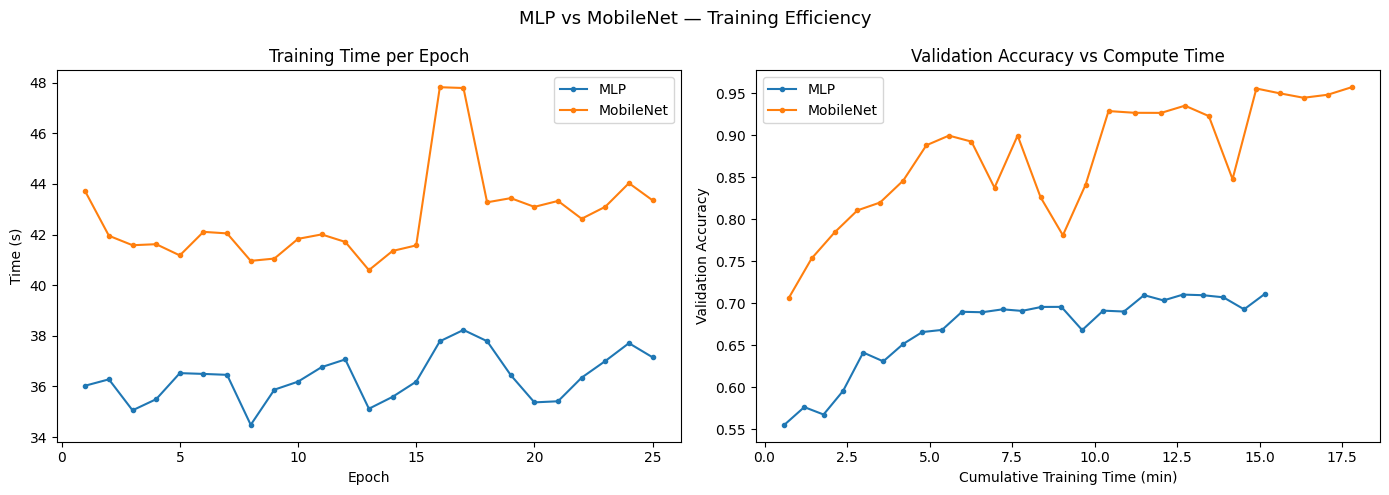

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(mlp_df) + 1)

# Training time per epoch
ax = axes[0]
ax.plot(epochs, mlp_df['train_times'], label='MLP', color='tab:blue', marker='o', markersize=3)
ax.plot(epochs, mn_df['train_times'], label='MobileNet', color='tab:orange', marker='o', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (s)')
ax.set_title('Training Time per Epoch')
ax.legend()

# Cumulative training time vs validation accuracy
ax = axes[1]
mlp_cum_time = mlp_df['train_times'].cumsum() / 60
mn_cum_time = mn_df['train_times'].cumsum() / 60
ax.plot(mlp_cum_time, mlp_df['valid_accs'], label='MLP', color='tab:blue', marker='o', markersize=3)
ax.plot(mn_cum_time, mn_df['valid_accs'], label='MobileNet', color='tab:orange', marker='o', markersize=3)
ax.set_xlabel('Cumulative Training Time (min)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Validation Accuracy vs Compute Time')
ax.legend()

fig.suptitle('MLP vs MobileNet — Training Efficiency', fontsize=13)
plt.tight_layout()
plt.show()

## Question 4

In [ ]:
img = np.array(Image.open('data/q4_data/train/image/0.png'))
msk = np.array(Image.open('data/q4_data/train/mask/0.png'))

In [ ]:
print(img.shape)
print(msk.shape)

(512, 512, 3)
(512, 512)


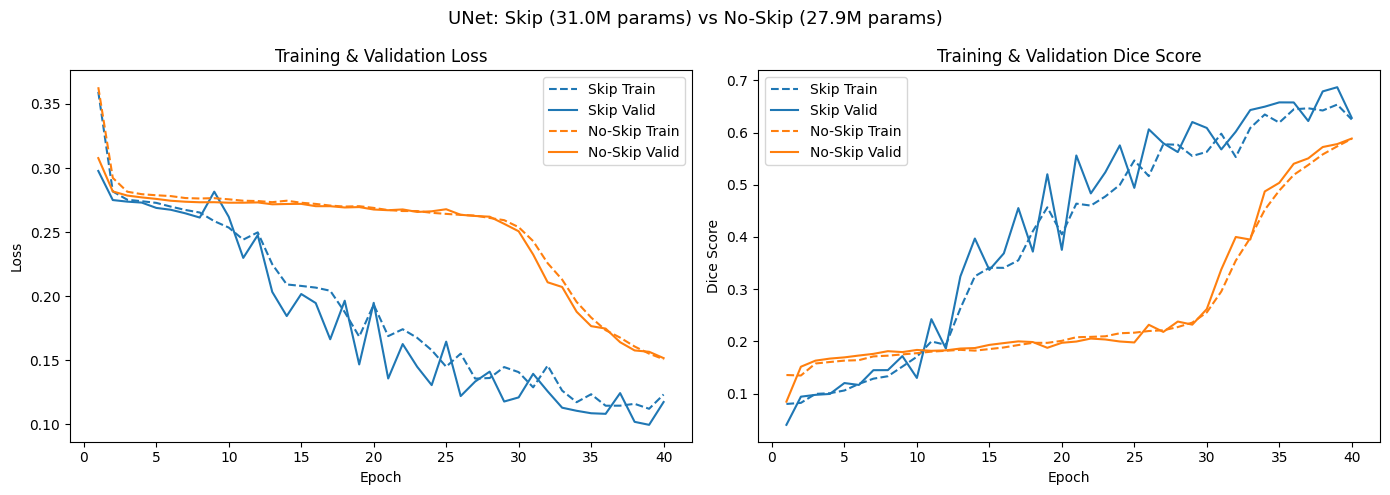

In [ ]:
with open('data/unet_results_20260220_180958.json') as f:
    skip_data = json.load(f)
with open('data/unet_results_20260220_183038.json') as f:
    noskip_data = json.load(f)

skip = skip_data['data']
noskip = noskip_data['data']
epochs = range(1, len(skip['train_losses']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(epochs, skip['train_losses'], label='Skip Train', linestyle='--', color='tab:blue')
ax.plot(epochs, skip['valid_losses'], label='Skip Valid', color='tab:blue')
ax.plot(epochs, noskip['train_losses'], label='No-Skip Train', linestyle='--', color='tab:orange')
ax.plot(epochs, noskip['valid_losses'], label='No-Skip Valid', color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()

# Dice Score (accuracy)
ax = axes[1]
ax.plot(epochs, skip['train_accs'], label='Skip Train', linestyle='--', color='tab:blue')
ax.plot(epochs, skip['valid_accs'], label='Skip Valid', color='tab:blue')
ax.plot(epochs, noskip['train_accs'], label='No-Skip Train', linestyle='--', color='tab:orange')
ax.plot(epochs, noskip['valid_accs'], label='No-Skip Valid', color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice Score')
ax.set_title('Training & Validation Dice Score')
ax.legend()

skip_params = skip_data['metadata']['env']['total_params'] / 1e6
noskip_params = noskip_data['metadata']['env']['total_params'] / 1e6
fig.suptitle(f'UNet: Skip ({skip_params:.1f}M params) vs No-Skip ({noskip_params:.1f}M params)', fontsize=13)
plt.tight_layout()
plt.show()

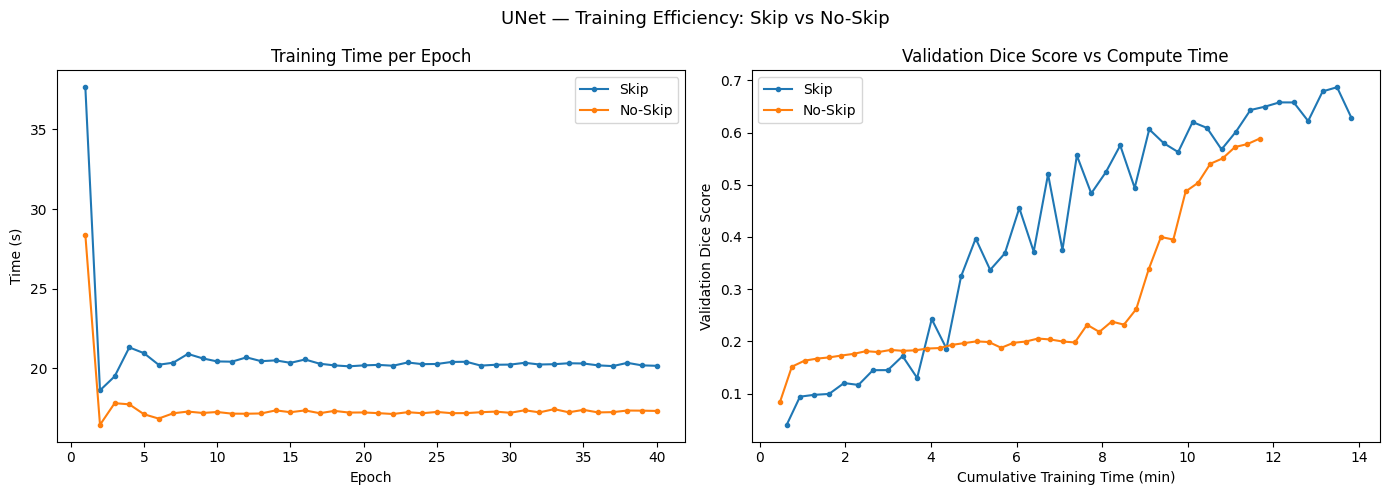

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time per epoch
ax = axes[0]
ax.plot(epochs, skip['train_times'], label='Skip', color='tab:blue', marker='o', markersize=3)
ax.plot(epochs, noskip['train_times'], label='No-Skip', color='tab:orange', marker='o', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (s)')
ax.set_title('Training Time per Epoch')
ax.legend()

# Cumulative time vs validation dice score
ax = axes[1]
skip_cum = np.cumsum(skip['train_times']) / 60
noskip_cum = np.cumsum(noskip['train_times']) / 60
ax.plot(skip_cum, skip['valid_accs'], label='Skip', color='tab:blue', marker='o', markersize=3)
ax.plot(noskip_cum, noskip['valid_accs'], label='No-Skip', color='tab:orange', marker='o', markersize=3)
ax.set_xlabel('Cumulative Training Time (min)')
ax.set_ylabel('Validation Dice Score')
ax.set_title('Validation Dice Score vs Compute Time')
ax.legend()

fig.suptitle('UNet — Training Efficiency: Skip vs No-Skip', fontsize=13)
plt.tight_layout()
plt.show()

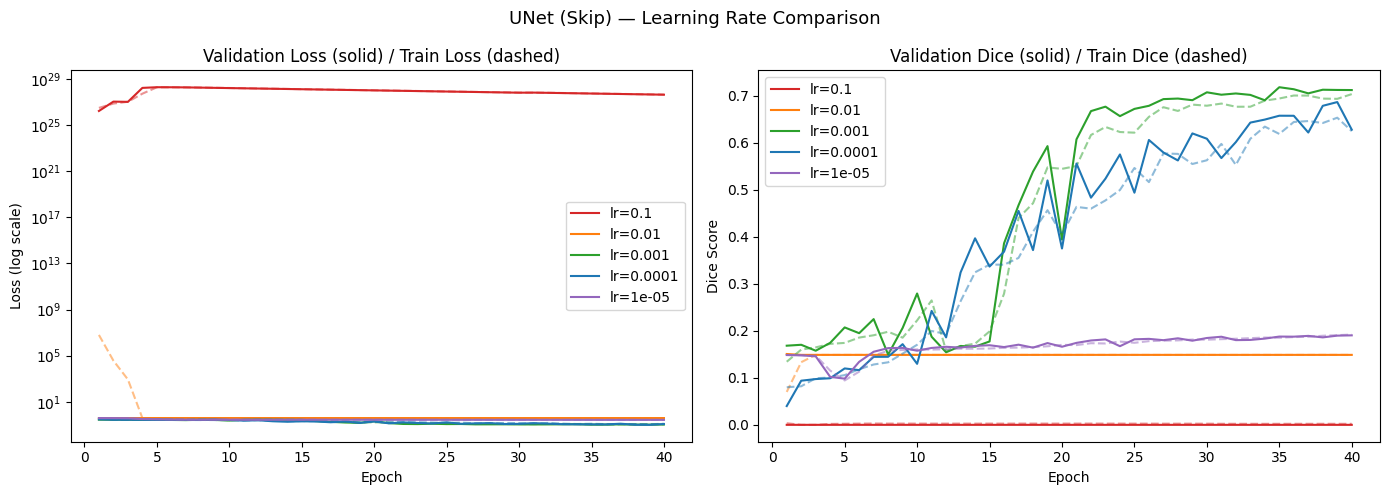

In [ ]:
# create plots that compare the loss and accuracy for each learning rate (all with skip_connections)
lr_files = {
    1e-1: 'data/unet_results_20260220_191733.json',
    1e-2: 'data/unet_results_20260220_193645.json',
    1e-3: 'data/unet_results_20260220_195357.json',
    1e-4: 'data/unet_results_20260220_180958.json',
    1e-5: 'data/unet_results_20260220_200937.json',
}

lr_runs = {}
for lr, path in lr_files.items():
    with open(path) as f:
        lr_runs[lr] = json.load(f)['data']

epochs = range(1, 41)
colors = ['tab:red', 'tab:orange', 'tab:green', 'tab:blue', 'tab:purple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss (log scale to handle lr=0.1 explosion)
ax = axes[0]
for (lr, data), color in zip(lr_runs.items(), colors):
    ax.plot(epochs, data['train_losses'], linestyle='--', color=color, alpha=0.5)
    ax.plot(epochs, data['valid_losses'], label=f'lr={lr}', color=color)
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (log scale)')
ax.set_title('Validation Loss (solid) / Train Loss (dashed)')
ax.legend()

# Dice Score
ax = axes[1]
for (lr, data), color in zip(lr_runs.items(), colors):
    ax.plot(epochs, data['train_accs'], linestyle='--', color=color, alpha=0.5)
    ax.plot(epochs, data['valid_accs'], label=f'lr={lr}', color=color)
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice Score')
ax.set_title('Validation Dice (solid) / Train Dice (dashed)')
ax.legend()

fig.suptitle('UNet (Skip) — Learning Rate Comparison', fontsize=13)
plt.tight_layout()
plt.show()

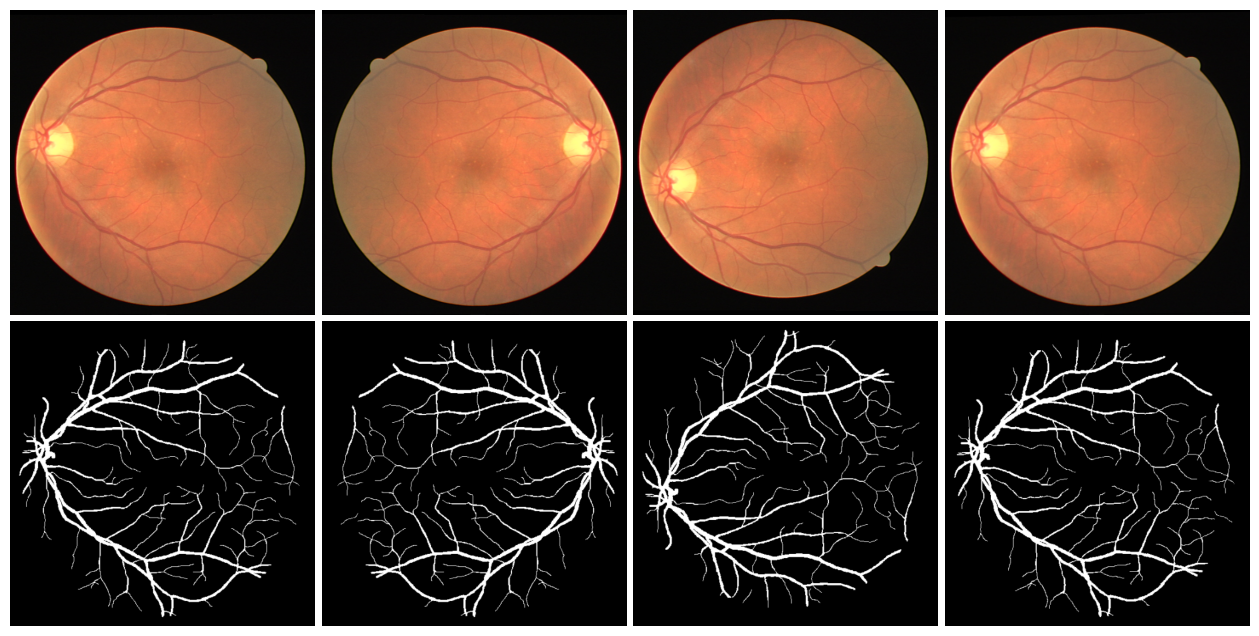

In [2]:
# create a plot with 2 rows and 4 columns. each column should be a pair of input image and mask. no labeling is necessary
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col in range(4):
    img = np.array(Image.open(f'data/q4_data/train/image/{col}.png'))
    msk = np.array(Image.open(f'data/q4_data/train/mask/{col}.png'))
    axes[0, col].imshow(img)
    axes[0, col].axis('off')
    axes[1, col].imshow(msk, cmap='gray')
    axes[1, col].axis('off')

plt.subplots_adjust(wspace=0.02, hspace=0.02)
plt.show()

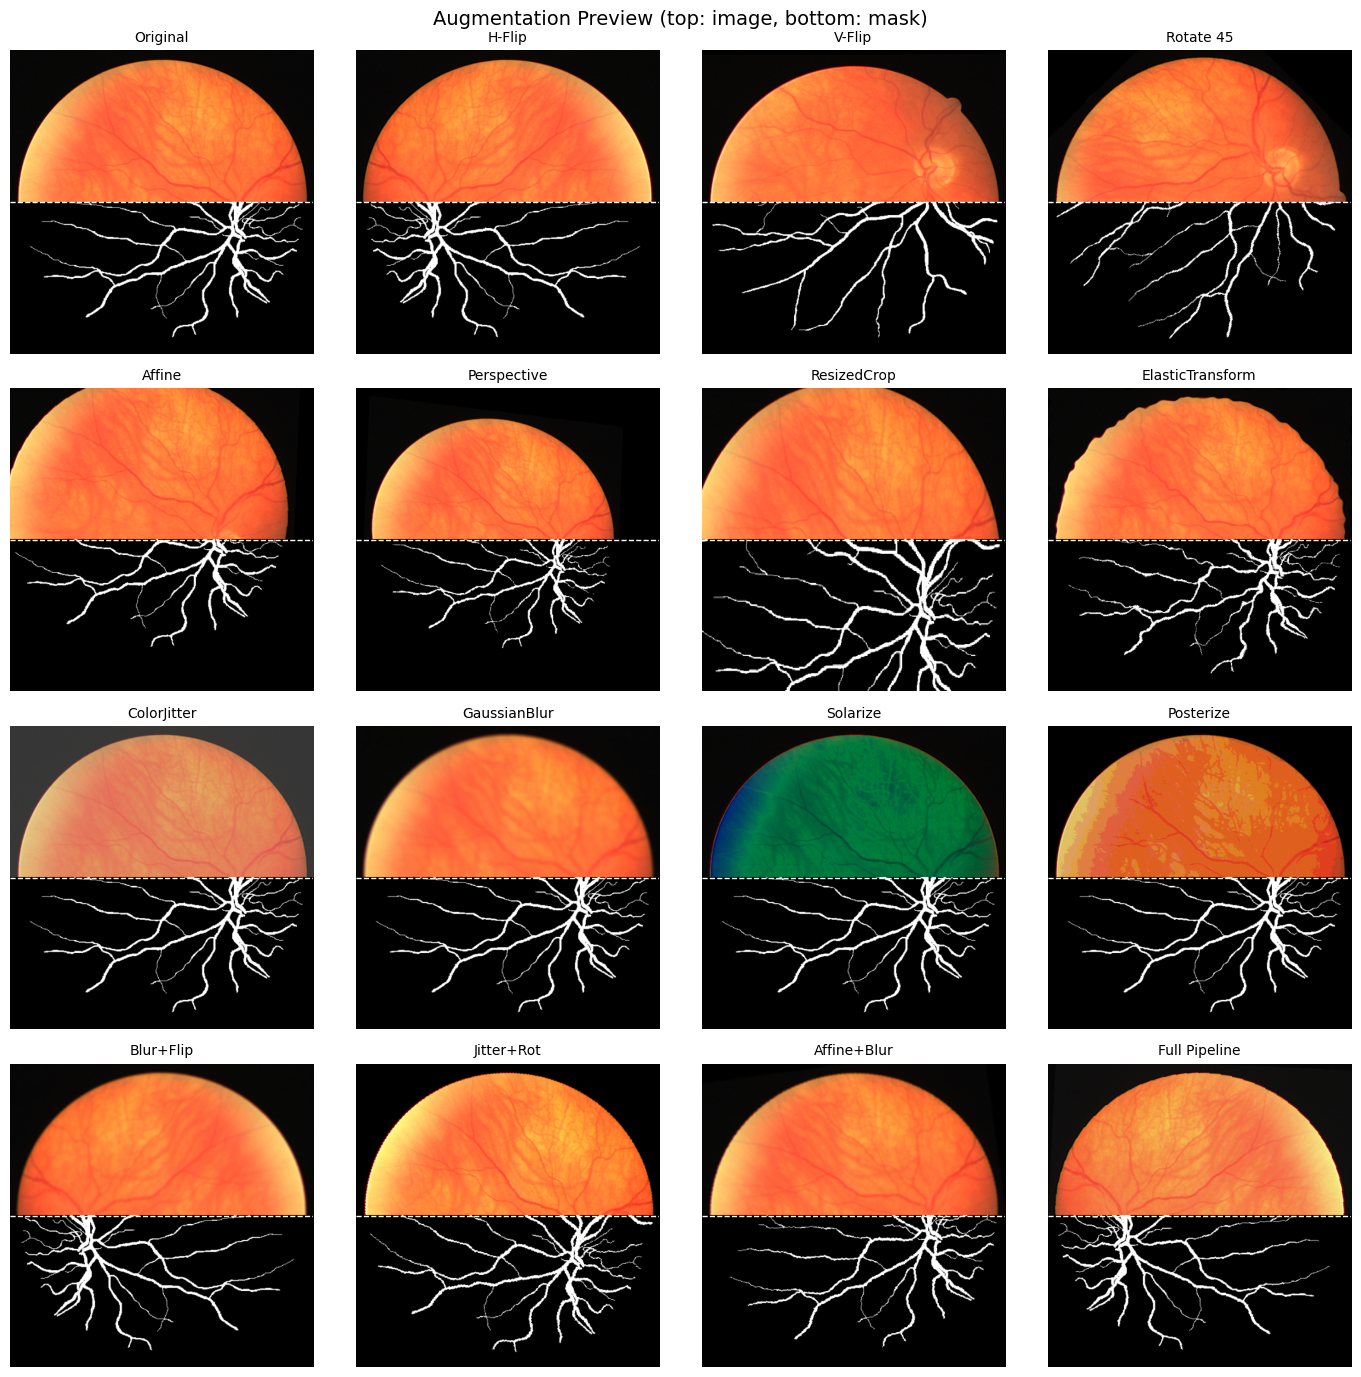

In [ ]:
from torchvision import tv_tensors
from torchvision.transforms import v2

img_idx = 10
img = np.array(Image.open(f'data/q4_data/train/image/{img_idx}.png'))
msk = np.array(Image.open(f'data/q4_data/train/mask/{img_idx}.png'))
image = tv_tensors.Image(torch.from_numpy((img / 255.0).astype(np.float32).transpose(2, 0, 1)))
mask = tv_tensors.Mask(torch.from_numpy((msk / 255.0).astype(np.float32)).unsqueeze(0))

transforms = [
    # Row 1: Geometry - flips & rotation
    ('Original', None),
    ('H-Flip', v2.RandomHorizontalFlip(p=1)),
    ('V-Flip', v2.RandomVerticalFlip(p=1)),
    ('Rotate 45', v2.RandomRotation(degrees=(45, 45))),
    # Row 2: Geometry - affine & crop
    ('Affine', v2.RandomAffine(degrees=(-15, 15), translate=(0.1, 0.1), scale=(0.8, 1.2))),
    ('Perspective', v2.RandomPerspective(distortion_scale=0.3, p=1)),
    ('ResizedCrop', v2.RandomResizedCrop(size=(512, 512), scale=(0.5, 1.0))),
    ('ElasticTransform', v2.ElasticTransform(alpha=100.0, sigma=5.0)),
    # Row 3: Color (image-only)
    ('ColorJitter', v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3)),
    ('GaussianBlur', v2.GaussianBlur(kernel_size=9, sigma=3.0)),
    ('Solarize', v2.RandomSolarize(threshold=0.5, p=1)),
    ('Posterize', v2.RandomPosterize(bits=3, p=1)),
    # Row 4: Composition
    ('Blur+Flip', v2.Compose([v2.GaussianBlur(kernel_size=7, sigma=2.0), v2.RandomHorizontalFlip(p=1)])),
    ('Jitter+Rot', v2.Compose([v2.ColorJitter(brightness=0.4, contrast=0.4), v2.RandomRotation(degrees=(-30, 30))])),
    ('Affine+Blur', v2.Compose([v2.RandomAffine(degrees=(-10, 10), scale=(0.9, 1.1)), v2.GaussianBlur(kernel_size=5, sigma=1.5)])),
    ('Full Pipeline', v2.Compose([v2.RandomHorizontalFlip(p=0.5), v2.RandomVerticalFlip(p=0.5), v2.RandomRotation(degrees=(-15, 15)), v2.ColorJitter(brightness=0.3, contrast=0.3)])),
]

cols = 4
rows = 4
fig, axes = plt.subplots(rows, cols, figsize=(14, 14))

for idx, (name, transform) in enumerate(transforms):
    r, c = divmod(idx, cols)
    if transform is not None:
        aug_img, aug_msk = transform(image, mask)
    else:
        aug_img, aug_msk = image, mask
    h = aug_img.shape[1]
    mid = h // 2
    img_np = aug_img.permute(1, 2, 0).numpy()
    msk_np = np.repeat(aug_msk.squeeze().numpy()[:, :, None], 3, axis=2)
    combined = np.concatenate([img_np[:mid], msk_np[mid:]], axis=0)
    axes[r, c].imshow(combined)
    axes[r, c].set_title(name, fontsize=10)
    axes[r, c].axhline(mid, color='white', linewidth=1, linestyle='--')
    axes[r, c].axis('off')

fig.suptitle('Augmentation Preview (top: image, bottom: mask)', fontsize=14)
plt.tight_layout()
plt.show()

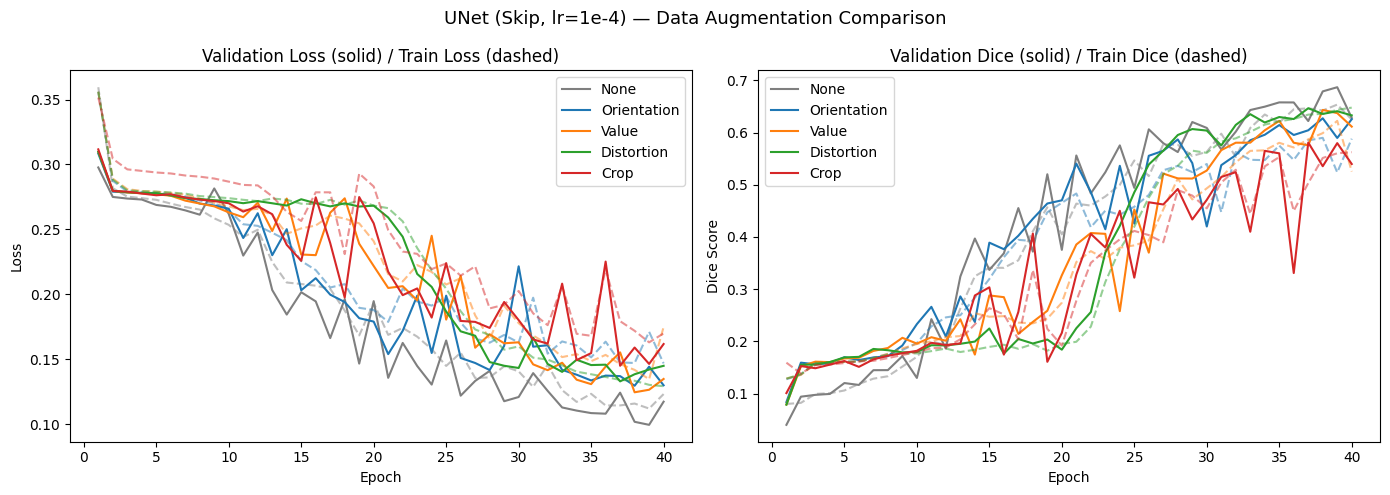

In [ ]:
# plot results from different augmentation strategies
aug_files = {
    'None': 'data/unet_results_20260220_180958.json',
    'Orientation': 'data/unet_results_20260220_223258.json',
    'Value': 'data/unet_results_20260220_224755.json',
    'Distortion': 'data/unet_results_20260220_230749.json',
    'Crop': 'data/unet_results_20260220_232251.json',
}

aug_runs = {}
for name, path in aug_files.items():
    with open(path) as f:
        aug_runs[name] = json.load(f)['data']

epochs = range(1, 41)
colors = ['tab:gray', 'tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
for (name, data), color in zip(aug_runs.items(), colors):
    ax.plot(epochs, data['train_losses'], linestyle='--', color=color, alpha=0.5)
    ax.plot(epochs, data['valid_losses'], label=name, color=color)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Validation Loss (solid) / Train Loss (dashed)')
ax.legend()

# Dice Score
ax = axes[1]
for (name, data), color in zip(aug_runs.items(), colors):
    ax.plot(epochs, data['train_accs'], linestyle='--', color=color, alpha=0.5)
    ax.plot(epochs, data['valid_accs'], label=name, color=color)
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice Score')
ax.set_title('Validation Dice (solid) / Train Dice (dashed)')
ax.legend()

fig.suptitle('UNet (Skip, lr=1e-4) — Data Augmentation Comparison', fontsize=13)
plt.tight_layout()
plt.show()

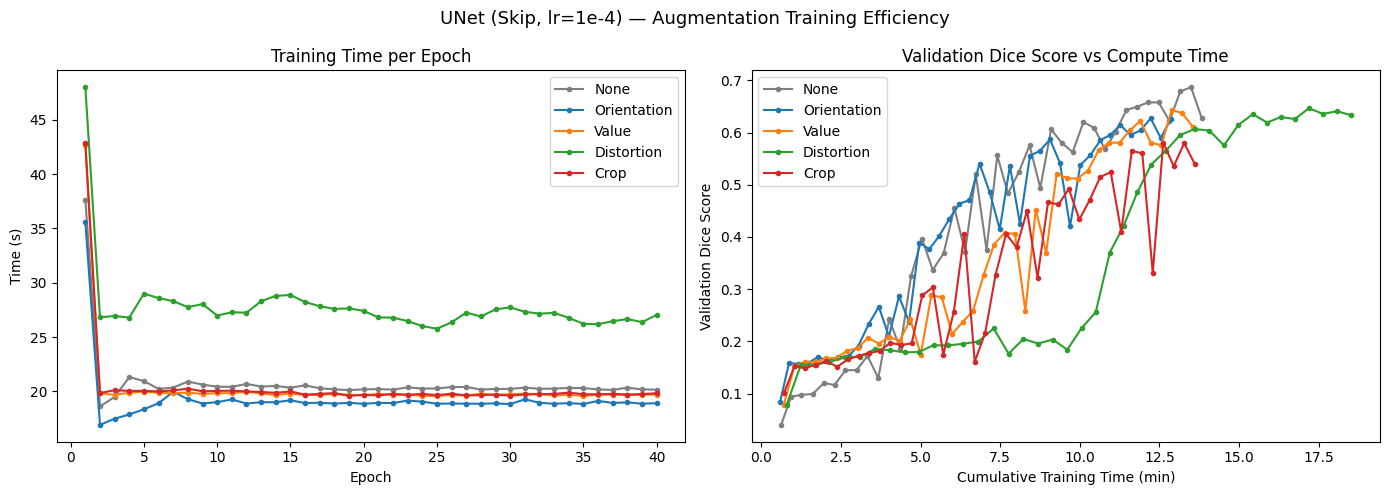

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time per epoch
ax = axes[0]
for (name, data), color in zip(aug_runs.items(), colors):
    ax.plot(epochs, data['train_times'], label=name, color=color, marker='o', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (s)')
ax.set_title('Training Time per Epoch')
ax.legend()

# Cumulative training time vs validation dice score
ax = axes[1]
for (name, data), color in zip(aug_runs.items(), colors):
    cum_time = np.cumsum(data['train_times']) / 60
    ax.plot(cum_time, data['valid_accs'], label=name, color=color, marker='o', markersize=3)
ax.set_xlabel('Cumulative Training Time (min)')
ax.set_ylabel('Validation Dice Score')
ax.set_title('Validation Dice Score vs Compute Time')
ax.legend()

fig.suptitle('UNet (Skip, lr=1e-4) — Augmentation Training Efficiency', fontsize=13)
plt.tight_layout()
plt.show()

### Pretrained

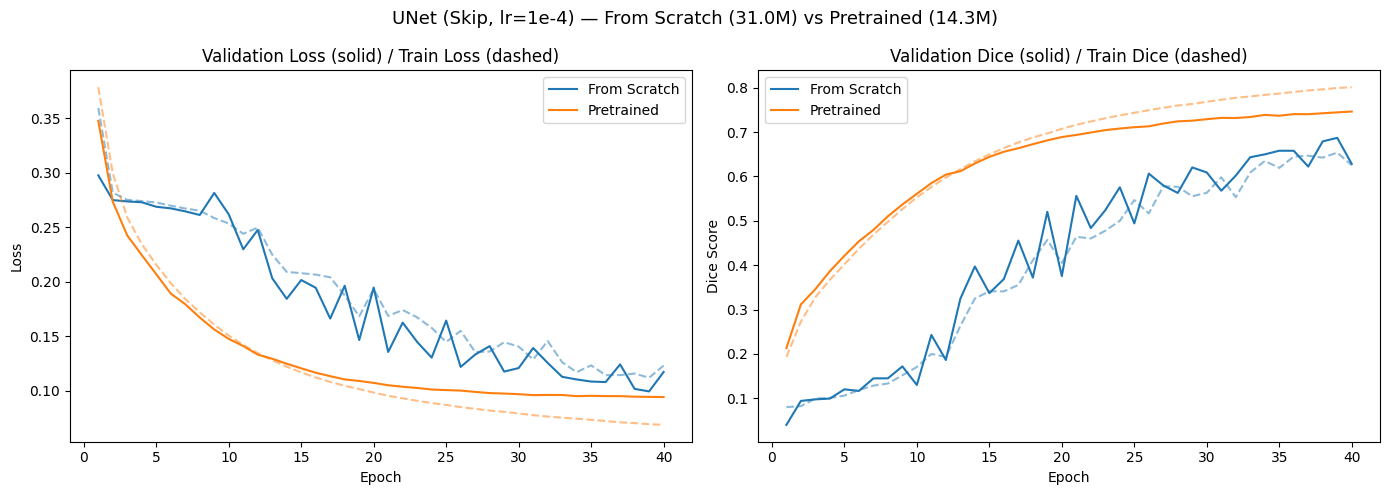

In [ ]:
with open('data/unet_results_20260220_180958.json') as f:
    baseline_data = json.load(f)
with open('data/pretrained_unet_results_20260221_165859.json') as f:
    pretrained_data = json.load(f)

baseline = baseline_data['data']
pretrained = pretrained_data['data']
epochs = range(1, len(baseline['train_losses']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(epochs, baseline['train_losses'], linestyle='--', color='tab:blue', alpha=0.5)
ax.plot(epochs, baseline['valid_losses'], label='From Scratch', color='tab:blue')
ax.plot(epochs, pretrained['train_losses'], linestyle='--', color='tab:orange', alpha=0.5)
ax.plot(epochs, pretrained['valid_losses'], label='Pretrained', color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Validation Loss (solid) / Train Loss (dashed)')
ax.legend()

# Dice Score
ax = axes[1]
ax.plot(epochs, baseline['train_accs'], linestyle='--', color='tab:blue', alpha=0.5)
ax.plot(epochs, baseline['valid_accs'], label='From Scratch', color='tab:blue')
ax.plot(epochs, pretrained['train_accs'], linestyle='--', color='tab:orange', alpha=0.5)
ax.plot(epochs, pretrained['valid_accs'], label='Pretrained', color='tab:orange')
ax.set_xlabel('Epoch')
ax.set_ylabel('Dice Score')
ax.set_title('Validation Dice (solid) / Train Dice (dashed)')
ax.legend()

baseline_params = baseline_data['metadata']['env']['total_params'] / 1e6
pretrained_params = pretrained_data['metadata']['env']['total_params'] / 1e6
fig.suptitle(f'UNet (Skip, lr=1e-4) — From Scratch ({baseline_params:.1f}M) vs Pretrained ({pretrained_params:.1f}M)', fontsize=13)
plt.tight_layout()
plt.show()

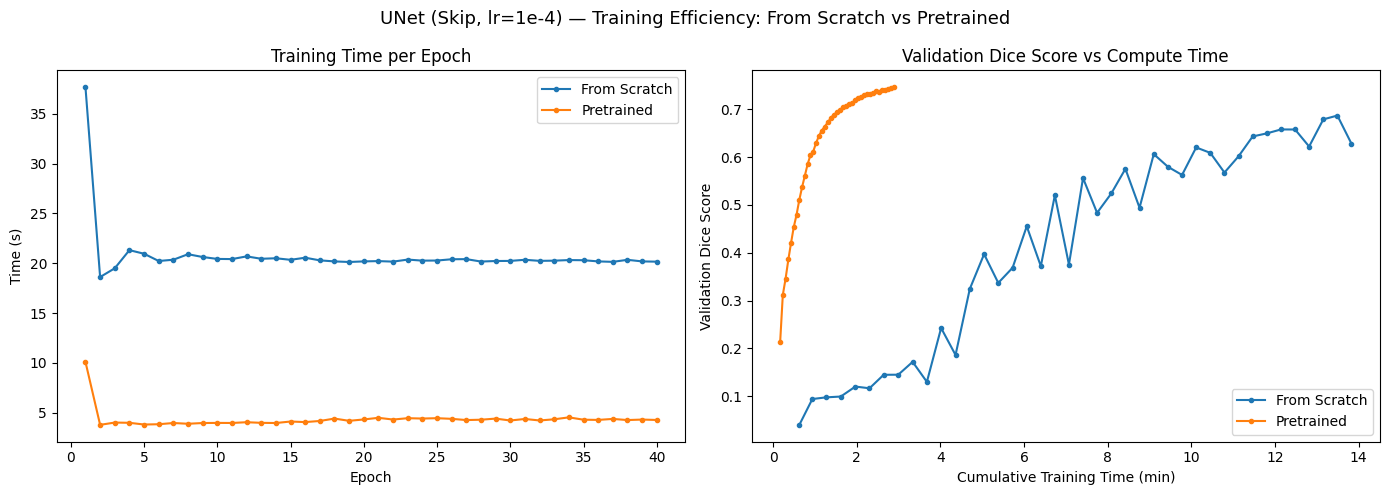

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time per epoch
ax = axes[0]
ax.plot(epochs, baseline['train_times'], label='From Scratch', color='tab:blue', marker='o', markersize=3)
ax.plot(epochs, pretrained['train_times'], label='Pretrained', color='tab:orange', marker='o', markersize=3)
ax.set_xlabel('Epoch')
ax.set_ylabel('Time (s)')
ax.set_title('Training Time per Epoch')
ax.legend()

# Cumulative training time vs validation dice score
ax = axes[1]
baseline_cum = np.cumsum(baseline['train_times']) / 60
pretrained_cum = np.cumsum(pretrained['train_times']) / 60
ax.plot(baseline_cum, baseline['valid_accs'], label='From Scratch', color='tab:blue', marker='o', markersize=3)
ax.plot(pretrained_cum, pretrained['valid_accs'], label='Pretrained', color='tab:orange', marker='o', markersize=3)
ax.set_xlabel('Cumulative Training Time (min)')
ax.set_ylabel('Validation Dice Score')
ax.set_title('Validation Dice Score vs Compute Time')
ax.legend()

fig.suptitle('UNet (Skip, lr=1e-4) — Training Efficiency: From Scratch vs Pretrained', fontsize=13)
plt.tight_layout()
plt.show()

In [33]:
a = np.array([
    [-1, 0 ,1],
    [-1, 0, 1],
    [-1, 0, 1],
])

In [35]:
# A simple 1D signal with a flat region, a sharp edge, and another flat region
signal = np.array([
    [5, 5, 5, 5, 9, 9, 9, 9, 9],
    [5, 5, 5, 5, 9, 9, 9, 9, 9],
    [5, 5, 5, 5, 9, 9, 9, 9, 9],
])  # 3×9 — minimum height to match the 3×3 kernel
result = convolve2d(signal, a, mode='valid')

print("Input row: ", signal[0])
print("Kernel:    ", a[1])  # middle row (all rows identical)
print("Output:    ", result[0])
print()
print("The kernel outputs 0 in flat regions and non-zero at the edge (5->9 transition).")
result

Input row:  [5 5 5 5 9 9 9 9 9]
Kernel:     [-1  0  1]
Output:     [  0   0 -12 -12   0   0   0]

The kernel outputs 0 in flat regions and non-zero at the edge (5->9 transition).


array([[  0,   0, -12, -12,   0,   0,   0]])